In [1]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt
from detection import bandpass_filter
from templates import build_template, template_match

waveforms = np.load("../data/raw/waveforms.npy")
valid_spike_times = np.load("../data/raw/valid_spike_times.npy")
ground_truth_spikes = np.load("../data/raw/c37_extracellular_spikes.npy")
cluster_labels = ... # we need this saved from notebook 04 — see note below

In [4]:
cluster_labels = np.load("../data/raw/cluster_labels.npy")

Template shape: (120, 40)


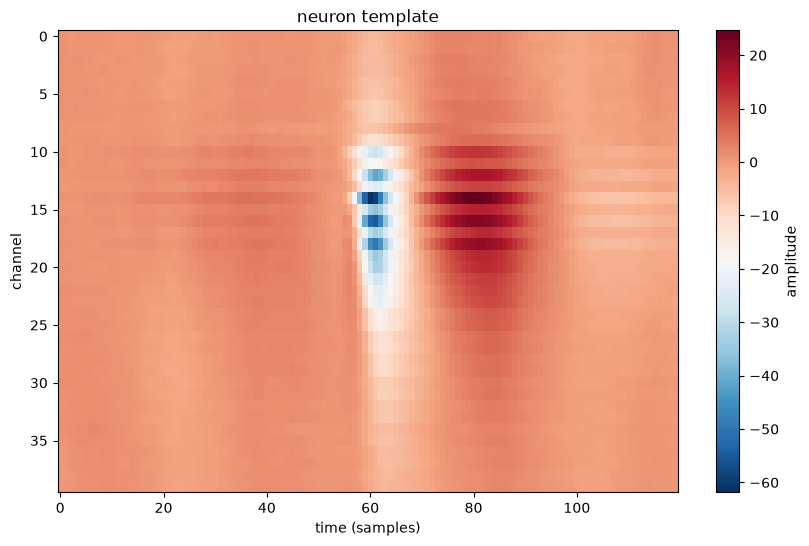

In [5]:
cluster_8_indices = np.where(cluster_labels == 8)[0]
template = build_template(waveforms, cluster_8_indices)
print(f"Template shape: {template.shape}")

plt.figure(figsize=(10, 6))
plt.imshow(template.T, aspect='auto', cmap='RdBu_r')
plt.xlabel("time (samples)")
plt.ylabel("channel")
plt.title("neuron template")
plt.colorbar(label="amplitude")
plt.savefig("../figures/template.png")
plt.show()

In [6]:
import time as timer

npx_recording = np.memmap("../data/raw/c37_npx_raw.bin", mode='r', dtype=np.int16, order='C')
npx_recording = npx_recording.reshape((384, 4050171), order='F')

channels_subset = list(range(180, 220))
subset_data = npx_recording[channels_subset, :].T.astype(np.float32)
fs = 30000
filtered = bandpass_filter(subset_data, fs)

# Test on just the first 5 seconds to check speed and correctness
test_segment = filtered[:fs*5, :]

start = timer.time()
matched_times, scores = template_match(test_segment, template, fs, threshold=0.7)
elapsed = timer.time() - start

print(f"Found {len(matched_times)} matches in 5 seconds, took {elapsed:.1f}s")

Found 4 matches in 5 seconds, took 0.6s


In [7]:
start = timer.time()
matched_times, scores = template_match(filtered, template, fs, threshold=0.7)
elapsed = timer.time() - start

print(f"Found {len(matched_times)} matches across full recording, took {elapsed:.1f}s")

Found 132 matches across full recording, took 17.4s


In [8]:
tolerance_samples = int(0.001 * fs)

matched_is_true = np.zeros(len(matched_times), dtype=bool)
true_found = np.zeros(len(ground_truth_spikes), dtype=bool)

for i, t in enumerate(matched_times):
    diffs = np.abs(ground_truth_spikes - t)
    close = diffs <= tolerance_samples
    if np.any(close):
        matched_is_true[i] = True
        true_found[close] = True

precision = matched_is_true.sum() / len(matched_times) * 100
recall = true_found.sum() / len(ground_truth_spikes) * 100

print(f"Template matching — Precision: {matched_is_true.sum()} / {len(matched_times)} matched a true spike ({precision:.1f}%)")
print(f"Template matching — Recall: found {true_found.sum()} / {len(ground_truth_spikes)} true spikes ({recall:.1f}%)")

Template matching — Precision: 101 / 132 matched a true spike (76.5%)
Template matching — Recall: found 101 / 601 true spikes (16.8%)


In [9]:
for thresh in [0.5, 0.6, 0.7, 0.8]:
    matched_times_t, _ = template_match(filtered, template, fs, threshold=thresh)
    matched_is_true_t = np.zeros(len(matched_times_t), dtype=bool)
    true_found_t = np.zeros(len(ground_truth_spikes), dtype=bool)
    for i, t in enumerate(matched_times_t):
        close = np.abs(ground_truth_spikes - t) <= tolerance_samples
        if np.any(close):
            matched_is_true_t[i] = True
            true_found_t[close] = True
    p = matched_is_true_t.sum() / len(matched_times_t) * 100 if len(matched_times_t) > 0 else 0
    r = true_found_t.sum() / len(ground_truth_spikes) * 100
    print(f"threshold={thresh}: precision={p:.1f}%, recall={r:.1f}%, n_matches={len(matched_times_t)}")

threshold=0.5: precision=9.5%, recall=67.4%, n_matches=4266
threshold=0.6: precision=37.4%, recall=42.6%, n_matches=685
threshold=0.7: precision=76.5%, recall=16.8%, n_matches=132
threshold=0.8: precision=100.0%, recall=1.7%, n_matches=10


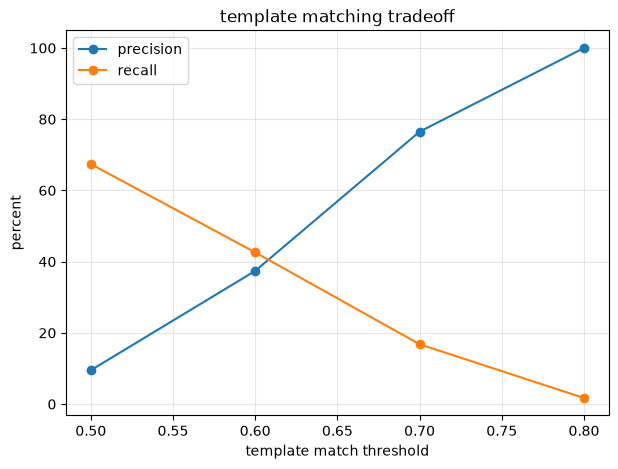

In [10]:
thresholds = [0.5, 0.6, 0.7, 0.8]
precisions = [9.5, 37.4, 76.5, 100.0]
recalls = [67.4, 42.6, 16.8, 1.7]

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions, marker='o', label='precision')
plt.plot(thresholds, recalls, marker='o', label='recall')
plt.xlabel("template match threshold")
plt.ylabel("percent")
plt.title("template matching tradeoff")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../figures/template_tradeoff.png")
plt.show()